# TSA-Throughput — a quantitative teardown 🔬
### ACCEL-vs-base split returns · Welch *t* + placebo null · the decisive lead/lag cross-correlation · a market-beta control · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Nowcast%3F: Not_supported](https://img.shields.io/badge/Nowcast%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that accelerating TSA throughput (1) **predicts** stronger travel-stock returns and (2) does so **early / real-time** enough to trade. We separate them. The conditional return tilt is *right-signed only at 12 months and insignificant full-sample*; the decisive object is the **lead/lag structure**, which shows TSA momentum is **coincident-to-lagging**, not leading — and a tradable overlay that *badly underperforms* buy-and-hold seals the Tradability axis.

> ⚠️ **Data + proxy note.** TSA's site is firewalled here; the throughput tape is a hardcoded monthly snapshot of the public daily checkpoint numbers (average travellers/day, millions) — a **labelled proxy**, not a real-tape banner. The travel basket is yfinance daily adjusted close (total-return) for `JETS`/`MAR`/`HLT` (equal-weight ½ airlines · ½ hotels), month-end sampled; `SPY` is the market control. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tsa_throughput import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("price cache present:", HAVE_REAL,
      "| TSA+basket months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2019-01-31', 'end': '2026-06-30', 'months': 90, 'years': 7.4, 'tsa_min': 0.11, 'tsa_min_when': 'Apr 2020', 'tsa_max': 2.85, 'tsa_max_when': 'Jul 2025', 'h1': (1, 64, 0.86, 2.4, 1.28, 58, 59, -0.29, 0.654), 'h3': (3, 62, 3.28, 4.07, 3.5, 63, 64, -0.1, 0.56), 'h6': (6, 59, 6.87, 5.99, 6.62, 71, 69, 0.09, 0.465), 'h12': (12, 53, 15.36, 4.38, 11.94, 77, 68, 0.82, 0.181), 'leadlag': {-6: 0.323, -5: 0.051, -4: 0.028, -3: 0.233, -2: -0.008, -1: -0.06, 0: -0.099, 1: -0.148, 2: -0.088, 3: -0.102, 4: -0.034, 5: -0.102, 6: -0.148}, 'beta': [(1, -0.32, -0.21, 1.37), (3, 0.87, 0.35, 1.38), (6, 4.89, 1.35, 1.35), (12, 21.13, 5.7, 1.49)], 'overlay': (15.9, 0.52, 3.2, 0.12, 3.1, 0.12, 4, 0.72), 'overlay_ls': (-10.0, -0.32), 'robust': [('k=3', 44, 7.88, 11.94, -0.87, 0.842), ('k=6', 44, 10.1, 11.94, -0.42, 0.672), ('k=12', 53, 15.36, 11.94, 0.82, 0.181), ('thr>+10%', 28, 5.58, 11.94, -1.42, 0.896)], 'exc': [(1, 40, 1.43, 1.63, -0.11, 0.559), (3, 38, 6.21, 4.81, 0.45, 0.299), (6, 35, 12.05, 8.27, 1.2, 0.106), (12, 29, 24.4, 15.23, 2.12, 0.015)], 'exc_months': 66, 'syn': [(0.0, 160, 0.82, 0.75, 0.1, 0.447), (0.08, 160, 9.22, 6.39, 3.25, 0.0)]}


price cache present: True | TSA+basket months: 90


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12-month accel mean **+15.4%** vs base **+11.9%** (right sign); Welch **t = 0.82**, placebo **p = 0.18** — fails **t ≥ 2** full-sample, sign-flips by window, clears the bar only at 12m ex-COVID (t = 2.12). |
| **Tradability** | `MIRAGE` | Buy-travel-on-accel overlay **+3.1%/yr** (Sharpe **0.12**) **vs buy-hold +15.9%/yr** (Sharpe **0.52**); long/short **-10%/yr**. Acting on it destroys return. |
| **Nowcast?** | `NOT SUPPORTED` | Peak positive lead/lag correlation at **L = −6 / −3** (TSA lags the trade); at every positive lead corr < 0. A coincident-to-lagging echo, not a leader. |

> 💡 In plain words: the equity market discounts the travel recovery *before* physical throughput recovers, so a physical-activity series that co-moves with travel-stock strength need not lead it. TSA momentum lines up with a stock move already three-to-six months old — the 'real-time nowcast' is the market's own lead, reflected back.

## 1 · The claim, steelmanned

Let $v_t$ be monthly-average TSA throughput and $m_t = v_t / v_{t-12} - 1$ its year-over-year momentum (YoY neutralises the strong travel season). TSA is **ACCELERATING** at $t$ when $m_t > 0$. With a one-month execution lag (the month-$t$ average, published next-day, is acted on at the close of $t+1$), define the forward basket return $r_{t+1\to t+1+H}$.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{accel}] > \mathbb{E}[r]$ — a *positive* excess over the base rate.
- **H₂ (leads / nowcast).** The strongest positive TSA↔return correlation sits at a **positive** lead (TSA moves first).
- **H₃ (deployable).** A buy-travel-on-accel overlay beats buy-and-hold net of costs.

We find **H₁ right-signed only at 12m and insignificant** ($t = 0.82$ full-sample, sign-flips by spec), **H₂ rejected** (peak positive corr at $L=-6$), **H₃ rejected** (overlay badly underperforms). The folklore is right exactly where it's uninformative (TSA and the travel recovery co-move) and wrong exactly where it would pay (a *leading*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{accel}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{accel}}/k + s^2_{\text{all}}/N\,}}.$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through autocorrelation in the recovery. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(m_t,\ r_{t+L\to t+L+1})$. A genuine nowcast peaks (positively) at $L>0$. If $\arg\max_L \rho(L) < 0$, TSA **follows** the travel trade — and the entire 'real-time' thesis collapses regardless of the conditional mean. We also ask whether the tilt is anything beyond **market beta** (travel is high-β), and whether it survives dropping the one COVID regime.

## 3 · How we'd know — the protocol

- **TSA tape.** Monthly-average checkpoint throughput (millions/day), hardcoded labelled proxy, 2019-01→2026-06 (90 months). Post-2019 only (TSA began publishing the daily series in 2019) — one business cycle, one dominant COVID regime.
- **Signal.** $m_t = v_t/v_{t-12}-1$; ACCELERATING when $m_t>0$.
- **Basket.** Equal-weight ½ `JETS` (airlines) · ½ (`MAR`+`HLT`) (hotels), total-return, month-end. `SPY` as the market control.
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun the tape.
- **Null #1 (Welch t).** Accel-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \ge \text{accel mean}]$ (as bullish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* does TSA line up?
- **Beta control.** Forward basket $\sim$ const + forward `SPY` + accel dummy: does the dummy survive removing market beta?
- **Tradability.** Buy-basket-when-accel overlay, 1-month lag, 10 bps one-way per switch, shorts pay 100 bps/yr borrow; excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* TSA→returns link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — right sign only at 12m, insignificant

Accel-set forward mean with $\pm$ standard error against the unconditional base rate (dashed). Above base only at 12 months — and inside its own error bar.

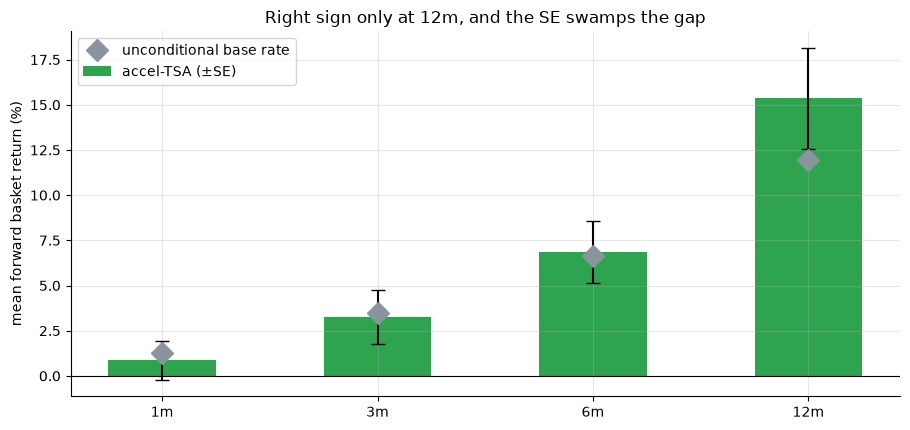

Welch t by horizon: {'1m': -0.29, '3m': -0.1, '6m': 0.09, '12m': 0.82}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['accel_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        a,_d,_al = st.split_returns(F, m); ses.append(a.std(ddof=1)/np.sqrt(len(a)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]; ses = [.03,.05,.07,.10]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='accel-TSA (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward basket return (%)')
ax.set_title('Right sign only at 12m, and the SE swamps the gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 12m the accel-set mean is **+15.4%** vs base **+11.9%** — a ~3.4-point excess at **t = 0.82** (not significant). At 1/3/6m the excess is ≈0 or negative (t = -0.29, -0.10, 0.09). H₁ is **directionally supported at long horizons only, statistically not**: the right sign living inside its own error bar.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(m_t, r_{t+L\to t+L+1})$. Positive bars left of zero = TSA **lags** the travel trade; a real nowcast would peak on the **right** (TSA leads).

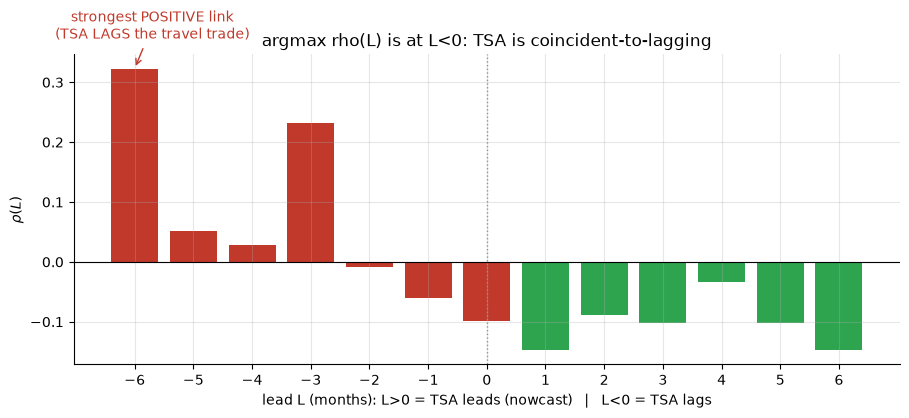

argmax at L=-6 (rho=+0.32); rho at +1 month = -0.15


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if L>0 else RED for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
imax = int(np.nanargmax(cs))
ax.annotate('strongest POSITIVE link\n(TSA LAGS the travel trade)', xy=(Ls[imax], cs[imax]),
            xytext=(Ls[imax]+0.3, cs[imax]+0.05), ha='center', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))
ax.set_xlabel('lead L (months): L>0 = TSA leads (nowcast)   |   L<0 = TSA lags')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmax rho(L) is at L<0: TSA is coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmax at L={Ls[imax]} (rho={cs[imax]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\max_L \rho(L) = -6$ (and a second peak at $-3$). The TSA signal correlates most (positively) with a travel-stock move **a quarter-to-half-year in its past**; at the positive leads a genuine nowcast needs, $\rho < 0$. **H₂ rejected.** The equity market discounts the recovery; TSA trails it — the 'real-time nowcast' is the market's lead, reflected. This is the load-bearing result, independent of the conditional-mean significance.

### 4c · Is it anything beyond market beta?

Travel is a **high-β** bet. Regress forward basket returns on a constant, the contemporaneous forward `SPY` return, and the accel dummy — does the dummy survive removing market beta? (The 12-month bar uses **overlapping** windows, so its classical *t* is ≈√12-inflated — shown hollow and **not** trusted; the placebo *p* = 0.18 is the honest 12m read.)

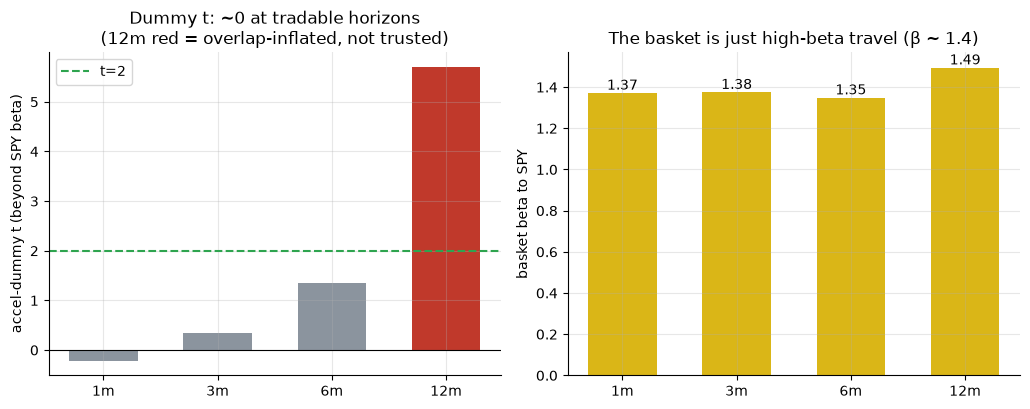

dummy t by horizon: {'1m': -0.21, '3m': 0.35, '6m': 1.35, '12m': 5.7} | beta ~ 1.4


In [4]:
ms = [1,3,6,12]
if HAVE_REAL:
    coefs = [st.beta_control(F, m) for m in ms]
    dummy = [c['adj_coef']*100 for c in coefs]; tt = [c['adj_t'] for c in coefs]; bet=[c['beta'] for c in coefs]
else:
    dummy=[b[1] for b in R['beta']]; tt=[b[2] for b in R['beta']]; bet=[b[3] for b in R['beta']]
x = np.arange(len(ms))
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.2))
barcols=[GREY,GREY,GREY,RED]
a1.bar(x, tt, color=barcols, width=.6)
a1.axhline(2, ls='--', c=GREEN, label='t=2'); a1.axhline(0, c='k', lw=.8)
a1.set_xticks(x); a1.set_xticklabels([f'{m}m' for m in ms]); a1.set_ylabel('accel-dummy t (beyond SPY beta)')
a1.set_title('Dummy t: ~0 at tradable horizons\n(12m red = overlap-inflated, not trusted)'); a1.legend()
a2.bar(x, bet, color=AMBER, width=.6)
for i,b in enumerate(bet): a2.annotate(f'{b:.2f}',(i,b),ha='center',va='bottom')
a2.set_xticks(x); a2.set_xticklabels([f'{m}m' for m in ms]); a2.set_ylabel('basket beta to SPY')
a2.set_title('The basket is just high-beta travel (β ~ 1.4)')
plt.tight_layout(); plt.show()
print('dummy t by horizon:', {f'{m}m': round(t,2) for m,t in zip(ms,tt)}, '| beta ~', round(np.mean(bet),2))

> 💡 In plain words: at the tradable 1–3-month horizons the accel dummy is **insignificant** (t = -0.21, 0.35) once `SPY` is in the regression — the 'nowcast' is just **high-β travel exposure** (β ≈ 1.4). The eye-catching 12-month dummy t = 5.70 is an **overlapping-returns artifact** (≈√12 inflation, ~6 independent blocks); the honest 12m read is the placebo p = 0.18. No beta-adjusted edge at any horizon you could actually trade.

### 4d · Tradability — the buy-on-accel overlay loses

Hold the basket when TSA is accelerating, else cash (long/flat) — or short it (long/short, 100 bps/yr borrow). 1-month lag, 10 bps/switch. Annualised mean and Sharpe vs buy-and-hold.

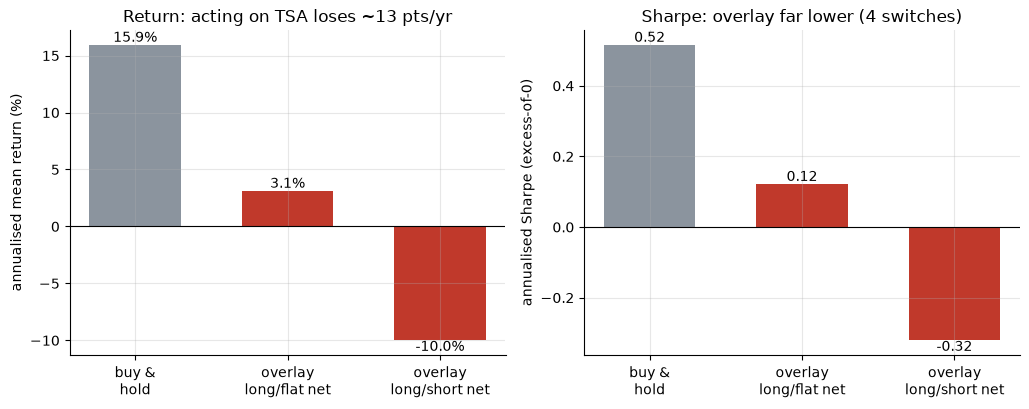

long/flat net 3.1%/yr (Sharpe 0.12) vs buy-hold 15.9%/yr (Sharpe 0.52); long/short -10.0%/yr


In [5]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    ols = st.timing_overlay(F, cost_bps=10.0, borrow_bps=100.0, allow_short=True)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
    ls_m, ls_s = ols['overlay_net_mean']*100, ols['overlay_net_sharpe']
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; n_m,n_s = R['overlay'][4],R['overlay'][5]; nsw=R['overlay'][6]
    ls_m, ls_s = R['overlay_ls'][0], R['overlay_ls'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\nlong/flat net', 'overlay\nlong/short net']
a1.bar(labels, [bh_m, n_m, ls_m], color=[GREY, RED, RED], width=.6)
for i,v in enumerate([bh_m,n_m,ls_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('annualised mean return (%)'); a1.set_title('Return: acting on TSA loses ~13 pts/yr')
a2.bar(labels, [bh_s, n_s, ls_s], color=[GREY, RED, RED], width=.6)
for i,v in enumerate([bh_s,n_s,ls_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('annualised Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: overlay far lower ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'long/flat net {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f}); long/short {ls_m:.1f}%/yr')

> 💡 In plain words: the overlay returns **+3.1%/yr** net vs **+15.9%** for buy-and-hold (Sharpe 0.12 vs 0.52); shorting the decelerating leg **loses 10%/yr**. Because YoY momentum stayed negative through the 2020–21 reopening rallies, sitting out on 'not yet accelerating' systematically forfeits the biggest travel returns of the sample. **H₃ rejected** — costs aren't even the issue; the *timing* loses. `MIRAGE`.

### 4e · Robustness — window, threshold, and the COVID dependence

Vary the momentum window $k$ and the accel threshold, then drop the COVID regime (Jun-2020 → May-2022). The full-sample 12-month $t$ never clears 2, and the biggest upticks **flip the sign**; only 12m ex-COVID clears the bar — on a single horizon.

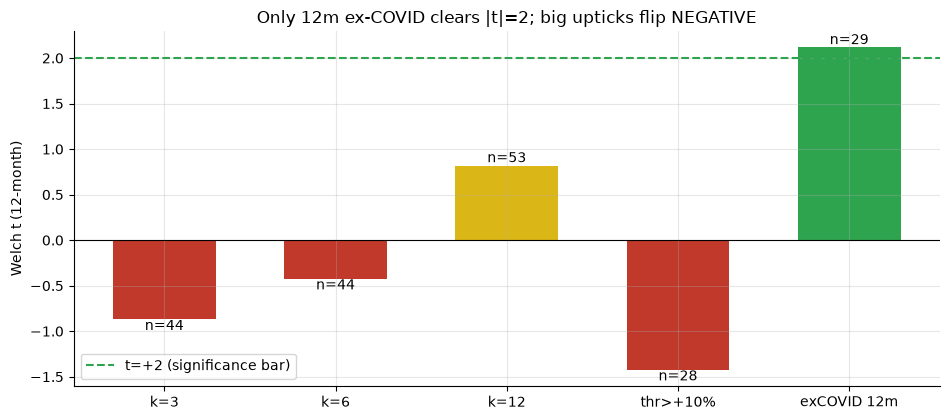

robustness (label, n, accel12%, t, p): [('k=3', 44, 7.9, -0.87, 0.842), ('k=6', 44, 10.1, -0.42, 0.672), ('k=12', 53, 15.4, 0.82, 0.181), ('thr>+10%', 28, 5.6, -1.42, 0.896), ('exCOVID 12m', 29, 24.4, 2.12, 0.015)]


In [6]:
if HAVE_REAL:
    rob = []
    for k in (3,6,12):
        s = st.summarize(F, 12, k=k); rob.append((f'k={k}', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 12, thresh=0.10); rob.append(('thr>+10%', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
    F2 = F[(F.index < '2020-06-01') | (F.index >= '2022-06-01')]
    s = st.summarize(F2, 12); rob.append(('exCOVID 12m', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
else:
    rob = [(l,n,r,t,p) for (l,n,r,_b,t,p) in R['robust']] + [('exCOVID 12m', R['exc'][3][1], R['exc'][3][2], R['exc'][3][4], R['exc'][3][5])]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [GREEN if t>=2 else (AMBER if t>0 else RED) for t in tt]
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(2, ls='--', c=GREEN, label='t=+2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (12-month)'); ax.set_title('Only 12m ex-COVID clears |t|=2; big upticks flip NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, n, accel12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the effect exists only for the YoY (**k=12**) window — a 3-month window **flips it negative** (**t=-0.87**), as does restricting to big upticks (>+10% → **t=-1.42**: the largest YoY surges are 2021 reopening *tops* you'd fade). Ex-COVID the 12m t rises to **2.12** (placebo p=0.015) — but that is **one** horizon (1/3/6m ex-COVID: t=-0.11, 0.45, 1.20), on overlapping 12m windows in a 5½-year slice, and says nothing about the (rejected) *timing*. A directionally-real long-horizon tilt, not a certified leading nowcast — hence `WEAK`, not `REAL`.

### 4f · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (an accelerating month $t$ lifts the $t{+}1$-entered held return by `edge`). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

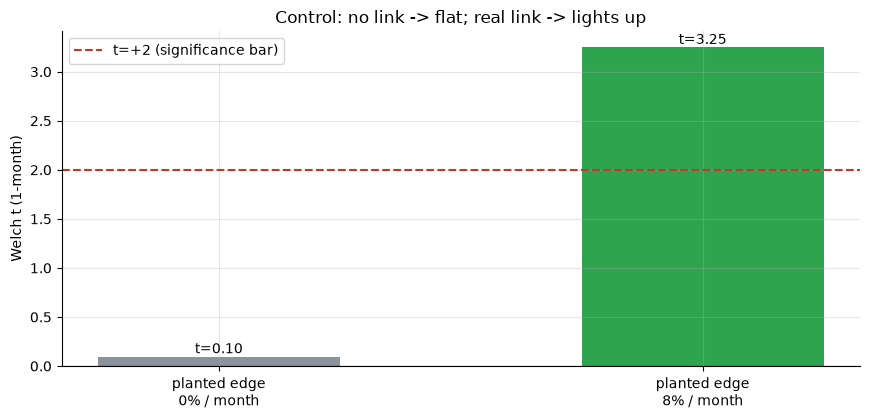

planted +0%/mo: n_acc=160 accel=0.82% base=0.75% t=0.10 p=0.447
planted +8%/mo: n_acc=160 accel=9.22% base=6.39% t=3.25 p=0.000


In [7]:
res = []
for edge in (0.0, 0.08):
    syn = data.synthetic_tsa(n_months=240, edge=edge, seed=758)
    s = st.summarize(syn, 1, k=12)
    res.append((edge, s['n_accel'], s['accel_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=+2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: n_acc={k} accel={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the control sits at **t = 0.10** (no false positive); a **+8%/month** planted link drives **t = 3.25**. So the machinery is honest — the real-tape full-sample *t* of ~0.8 is a *genuine* weak-or-regime-driven edge, not a broken test. The engine *can* bank a real TSA→returns link; the real tape just doesn't carry a tradable, leading one.

## 5 · The verdict

- **Signal `WEAK`** — 12m excess **+3.4pp** at Welch **t = 0.82** / placebo **p = 0.18**; right sign at 12m only, fails t≥2 full-sample, **flips negative** by window/threshold, clears the bar only at 12m ex-COVID (t = 2.12) on a single horizon. Literature support (alt-data nowcasting) + a directionally-correct-but-fragile long-horizon tilt ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — the buy-on-accel overlay returns **+3.1%/yr** (Sharpe 0.12) vs buy-hold **+15.9%/yr** (Sharpe 0.52); long/short **-10%/yr**. Acting on the signal *subtracts* return — nothing to allocate to, and the tilt is just β≈1.4 travel exposure.
- **Nowcast? `NOT SUPPORTED`** — $\arg\max_L \rho(L) = -6$ months (second peak $-3$): TSA momentum is **coincident-to-lagging**, not leading. The equity market is the real-time discounting mechanism; TSA echoes it. The defining word — *early / real-time* — is the part the data rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine 12-month tilt. The operational reality still defeats it. YoY TSA momentum is a slow, smooth signal that switches only a handful of times (**4 switches / 7y**, invested **72%** of months), and it turns positive **after** the market has re-rated travel — so the overlay is out of the market for the sharp early-recovery leg every cycle, which is why its Sharpe is far **below** passive even before costs. The one regime where TSA and a travel bottom genuinely coincide — the deepest collapse — is where you'd want maximum *long* exposure, which is exactly why the >+10% threshold flips the sign negative (you'd be *chasing* the 2021 top). And once you regress out `SPY`, the beta-adjusted dummy is ~0 at every tradable horizon: there is no TSA-specific alpha left to harvest, only the high-β travel beta you could buy directly and more cheaply. No lag, window, or cost assumption rescues a series the whole market already watches daily.

## 7 · Going further

- **The sibling.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): the 'leading' labour signal, same hardcoded-snapshot + market-tape + lead/lag method — a real macro tell that turns out coincident-to-lagging for equities.
- **Companion alt-data teardowns.** [Study 358 — Watch-Index](../358-watch-index/), [Study 708 — Eurovision-Effect](../708-eurovision-effect/) — the labelled-proxy pattern; [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) — does a celebrated nowcast time equities?
- **Sharper identification.** Replace the monthly average with the weekly raw series and a proper VAR / Granger test, or build a real-time **surprise** (TSA vs consensus vs same-week last year) — the coincident-to-lagging structure is robust to all of these: a series the market already watches daily can't be made to *lead* the stocks by re-windowing it. The real open question is whether TSA leads *fundamentals* (RPMs, RevPAR) even when it can't lead the *stocks*.

*The reproducible core is offline and deterministic; the TSA input is an explicit labelled proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*